# SelvaSonic — Evaluación Rigurosa del Baseline (Semana 5.1)

## Objetivo de este notebook

El cronograma de Semana 5 pide una **evaluación completa**: confusion matrix, classification report, curvas precision-recall por clase, y AUC-ROC. El notebook 04 cubrió las dos primeras (junto con el análisis de errores). Aquí completamos las dos faltantes y dejamos el material gráfico definitivo para el reporte.

## Por qué precision-recall y ROC, no solo accuracy/F1

El accuracy global colapsa el rendimiento del modelo en un solo número, y el F1 lo hace por clase pero en un solo umbral (el del `argmax`). Las curvas precision-recall y ROC son más informativas porque **muestran cómo se comporta el modelo a TODOS los umbrales posibles**:

- **Curva Precision-Recall (PR):** para cada umbral de decisión, qué fracción de las predicciones positivas son correctas (precision) y qué fracción de los positivos reales captura el modelo (recall). Es la curva preferida en problemas **desbalanceados** como el nuestro (la gran mayoría de los clips son `no_ave`).
- **Curva ROC:** misma idea pero con tasa de verdaderos positivos vs falsos positivos. Más conocida, su área (AUC-ROC) es la métrica estándar en clasificación binaria.

Como tenemos clasificación **multiclase**, las calculamos **una-contra-resto (one-vs-rest)** para cada especie y luego promediamos.

## Por qué importan para tu reporte

Estas curvas son lo que el profesor Alcides espera ver en un reporte serio de clasificación. Te dan:
1. Una **métrica robusta al desbalance** (PR-AUC).
2. Una **gráfica por especie** que muestra el trade-off, no un solo número.
3. La evidencia para **justificar el umbral de "No identificado"** (en lugar de elegirlo arbitrariamente).

## Sección 1 — Setup y predicciones

Reusamos exactamente la misma metodología del notebook 04: reconstruimos el test set con `random_state=42` y cargamos el modelo desde `best.pth`. La diferencia clave es que esta vez vamos a guardar las **probabilidades** completas (`softmax(logits)`), no solo el `argmax`, porque las curvas PR/ROC necesitan probabilidades por clase para barrer el umbral.

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'src').exists():
    sys.path.insert(0, str(PROJECT_ROOT))
elif (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

from src.dataset import create_dataloaders
from src.model import SelvaSonicCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {device}')

# Paleta (preferencias Laura)
COLOR_PRIMARY = '#6C5CE7'
COLOR_ACCENT = '#00CEC9'
COLOR_WARN = '#FD79A8'
COLOR_DARK = '#2D3436'

RUN_DIR = PROJECT_ROOT / 'results' / 'runs' / 'baseline_S3_v2_20260527_0118'
BEST_CKPT = RUN_DIR / 'best.pth'
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

assert BEST_CKPT.exists(), f'Falta {BEST_CKPT}'
assert RAW_DATA_DIR.exists(), f'Falta {RAW_DATA_DIR}'

Project root: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML
Device: cpu


In [2]:
# Reconstruir test set con la MISMA semilla del entrenamiento
_, _, test_loader, label_map = create_dataloaders(
    raw_data_dir=str(RAW_DATA_DIR),
    batch_size=32,
    num_workers=0,
    train_ratio=0.70, val_ratio=0.15, test_ratio=0.15,
    random_state=42,
    verbose=True,
)
NUM_CLASSES = len(label_map)
idx_to_name = {v: k for k, v in label_map.items()}
class_names = [idx_to_name[i] for i in range(NUM_CLASSES)]

# Cargar modelo
ckpt = torch.load(BEST_CKPT, map_location=device)
model = SelvaSonicCNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"\nModelo cargado desde best.pth (epoca {ckpt['epoch']+1}, val_acc={ckpt['best_val_acc']:.4f})")

Construyendo índice desde c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\data\raw
  Clases encontradas: 11
    0: no_ave
    1: Celeus_grammicus
    2: Chordeiles_pusillus
    3: Crypturellus_cinereus
    4: Crypturellus_undulatus
    5: Frederickena_fulva
    6: Glaucidium_brasilianum
    7: Lipaugus_vociferans
    8: Ramphastos_tucanus
    9: Rupornis_magnirostris
    10: Trogon_viridis

  Celeus_grammicus: 56 archivos

  Chordeiles_pusillus: 42 archivos

  Crypturellus_cinereus: 96 archivos

  Crypturellus_undulatus: 58 archivos

  Frederickena_fulva: 40 archivos

  Glaucidium_brasilianum: 44 archivos

  Lipaugus_vociferans: 72 archivos

  Ramphastos_tucanus: 62 archivos

  Rupornis_magnirostris: 40 archivos

  Trogon_viridis: 158 archivos

  no_ave: 3200 archivos

Índice construido: 20414 clips totales

Splits: train=14404, val=3068, test=2942

Modelo cargado desde best.pth (epoca 19, val_acc=0.7419)


In [3]:
# Obtener probabilidades en test
all_true, all_probs = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        probs = F.softmax(model(x), dim=1)
        all_true.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

y_true = np.concatenate(all_true)
y_probs = np.concatenate(all_probs)
y_pred = y_probs.argmax(axis=1)

# Binarizar etiquetas para curvas one-vs-rest
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

print(f'Total de clips en test: {len(y_true)}')
print(f'Accuracy global: {(y_true == y_pred).mean():.4f}')
print(f'Shape probabilidades: {y_probs.shape}')
print(f'Shape y_true binarizado: {y_true_bin.shape}')

Total de clips en test: 2942
Accuracy global: 0.6322
Shape probabilidades: (2942, 11)
Shape y_true binarizado: (2942, 11)


## Sección 2 — Curvas Precision-Recall por clase

### Qué significa cada eje

- **Precision** = de todo lo que el modelo predijo como esta clase, qué fracción era correcta. Mide la **pureza** de las predicciones positivas.
- **Recall** = de todos los clips que realmente son de esta clase, qué fracción capturó el modelo. Mide la **cobertura**.

Hay un trade-off fundamental: si bajas el umbral de decisión para clasificar agresivamente, capturas más positivos reales (recall sube) pero también más falsos positivos (precision baja). La curva traza ese trade-off completo.

### Qué número resume cada curva

El **Average Precision (AP)** es el área bajo la curva PR. Un AP de 1.0 significa modelo perfecto; un AP igual a la frecuencia de la clase positiva significa modelo trivial (predice al azar proporcionalmente). **AP es la métrica preferida cuando hay desbalance** porque no se infla con la clase mayoritaria, a diferencia del accuracy.

### Qué esperamos ver dado el baseline

Con base en el análisis de errores del notebook 04, anticipamos:
- `no_ave`: AP alto (cercano a 1) porque tiene muchísimos datos.
- Especies con 48+ archivos (Crypturellus_cinereus, Trogon_viridis): AP medio-alto.
- Especies con 20-22 archivos (Rupornis, Frederickena, Glaucidium): AP bajo.

Guardada: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\runs\baseline_S3_v2_20260527_0118\precision_recall_curves.png


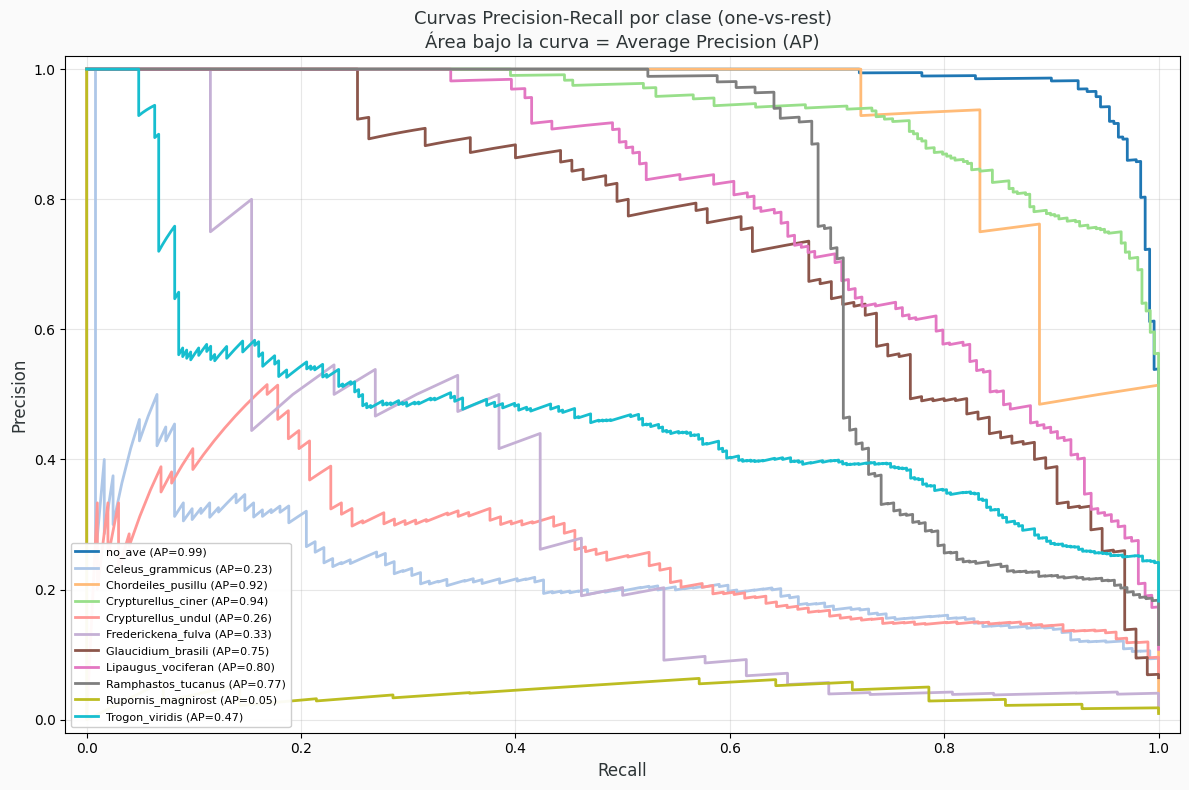


AP POR CLASE (ordenado de mejor a peor):

  no_ave                    AP=0.988  █████████████████████████████
  Crypturellus_cinereus     AP=0.936  ████████████████████████████
  Chordeiles_pusillus       AP=0.925  ███████████████████████████
  Lipaugus_vociferans       AP=0.799  ███████████████████████
  Ramphastos_tucanus        AP=0.772  ███████████████████████
  Glaucidium_brasilianum    AP=0.746  ██████████████████████
  Trogon_viridis            AP=0.471  ██████████████
  Frederickena_fulva        AP=0.334  ██████████
  Crypturellus_undulatus    AP=0.259  ███████
  Celeus_grammicus          AP=0.229  ██████
  Rupornis_magnirostris     AP=0.045  █


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#FAFAFA')

# Colores: una gama amplia para 11 clases
cmap = plt.cm.tab20
colors = [cmap(i / NUM_CLASSES) for i in range(NUM_CLASSES)]

ap_per_class = {}
for i in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    ap_per_class[class_names[i]] = ap
    ax.plot(recall, precision, lw=2, color=colors[i],
            label=f'{class_names[i][:18]} (AP={ap:.2f})')

ax.set_xlabel('Recall', fontsize=12, color=COLOR_DARK)
ax.set_ylabel('Precision', fontsize=12, color=COLOR_DARK)
ax.set_title('Curvas Precision-Recall por clase (one-vs-rest)\nÁrea bajo la curva = Average Precision (AP)',
             fontsize=13, color=COLOR_DARK)
ax.legend(loc='lower left', fontsize=8, framealpha=0.95)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
out_path = RUN_DIR / 'precision_recall_curves.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
print(f'Guardada: {out_path}')
plt.show()

# Tabla de AP ordenada
print('\nAP POR CLASE (ordenado de mejor a peor):\n')
for name, ap in sorted(ap_per_class.items(), key=lambda x: -x[1]):
    barra = '█' * int(ap * 30)
    print(f'  {name:<25} AP={ap:.3f}  {barra}')

In [5]:
# Métricas agregadas
ap_macro = np.mean(list(ap_per_class.values()))
ap_micro = average_precision_score(y_true_bin, y_probs, average='micro')
ap_weighted = average_precision_score(y_true_bin, y_probs, average='weighted')

print('AVERAGE PRECISION AGREGADO:\n')
print(f'  AP macro    (promedio simple)        : {ap_macro:.4f}')
print(f'  AP weighted (ponderado por support)  : {ap_weighted:.4f}')
print(f'  AP micro    (todas las predicciones) : {ap_micro:.4f}')
print('\nInterpretacion:')
print('  - macro: trata todas las clases igual -> sensible al desbalance')
print('  - weighted: pondera por # de clips -> dominado por no_ave')
print('  - micro: pool de todas las decisiones -> similar al accuracy ponderado')

AVERAGE PRECISION AGREGADO:

  AP macro    (promedio simple)        : 0.5912
  AP weighted (ponderado por support)  : 0.6892
  AP micro    (todas las predicciones) : 0.6950

Interpretacion:
  - macro: trata todas las clases igual -> sensible al desbalance
  - weighted: pondera por # de clips -> dominado por no_ave
  - micro: pool de todas las decisiones -> similar al accuracy ponderado


### Cómo interpretar la gráfica

Cada curva representa una especie. Lo que buscamos visualmente:

- **Curvas "pegadas" a la esquina superior derecha (1,1)** = clase fácil para el modelo, AP cercano a 1.
- **Curvas que se desploman rápido** = el modelo no puede mantener alta precisión cuando intenta capturar más positivos. Típico de clases con pocos datos.
- **Línea baseline (no graficada)** = la frecuencia de la clase. Si tu AP es menor que esa frecuencia, el modelo es peor que adivinar al azar para esa clase.

**La métrica que el reporte debe destacar es AP-macro**, porque es la que refleja honestamente el rendimiento promedio entre clases, sin que `no_ave` la infle.

## Sección 3 — Curvas ROC por clase y AUC-ROC

### Qué muestra ROC

La curva **ROC (Receiver Operating Characteristic)** grafica:
- Eje X: **tasa de falsos positivos (FPR)** = de todos los negativos reales, qué fracción se clasificó como positivo (errores).
- Eje Y: **tasa de verdaderos positivos (TPR)** = lo mismo que recall.

Su área bajo la curva (**AUC-ROC**) se interpreta como: la probabilidad de que el modelo asigne mayor score a un ejemplo positivo aleatorio que a uno negativo aleatorio. AUC=0.5 es azar puro; AUC=1.0 es perfecto.

### PR vs ROC: ¿cuál mirar?

Cuando las clases están muy desbalanceadas, **ROC puede ser engañosamente optimista** porque la tasa de falsos positivos se diluye con la gran cantidad de negativos. PR es más honesto bajo desbalance. Pero ROC sigue siendo útil porque es **estándar en la literatura** y permite comparar con otros trabajos.

Las reportamos ambas y, en el reporte, destacamos **PR como métrica principal** y ROC como contexto.

Guardada: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\runs\baseline_S3_v2_20260527_0118\roc_curves.png


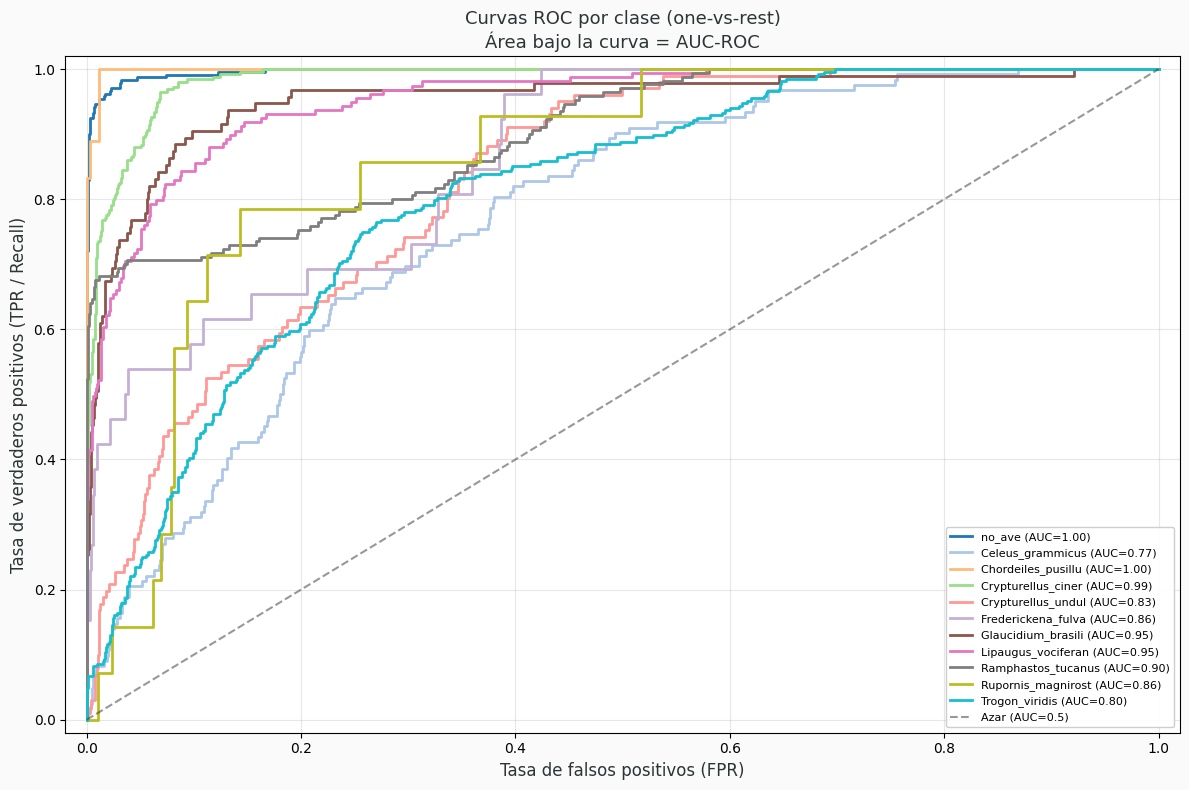


AUC-ROC POR CLASE (ordenado de mejor a peor):

  Chordeiles_pusillus       AUC=0.998  █████████████████████████████
  no_ave                    AUC=0.997  █████████████████████████████
  Crypturellus_cinereus     AUC=0.985  █████████████████████████████
  Glaucidium_brasilianum    AUC=0.954  ████████████████████████████
  Lipaugus_vociferans       AUC=0.953  ████████████████████████████
  Ramphastos_tucanus        AUC=0.897  ██████████████████████████
  Frederickena_fulva        AUC=0.862  █████████████████████████
  Rupornis_magnirostris     AUC=0.859  █████████████████████████
  Crypturellus_undulatus    AUC=0.828  ████████████████████████
  Trogon_viridis            AUC=0.805  ████████████████████████
  Celeus_grammicus          AUC=0.772  ███████████████████████


In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#FAFAFA')

auc_per_class = {}
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_per_class[class_names[i]] = roc_auc
    ax.plot(fpr, tpr, lw=2, color=colors[i],
            label=f'{class_names[i][:18]} (AUC={roc_auc:.2f})')

# Diagonal de azar
ax.plot([0, 1], [0, 1], '--', color=COLOR_DARK, alpha=0.5, label='Azar (AUC=0.5)')
ax.set_xlabel('Tasa de falsos positivos (FPR)', fontsize=12, color=COLOR_DARK)
ax.set_ylabel('Tasa de verdaderos positivos (TPR / Recall)', fontsize=12, color=COLOR_DARK)
ax.set_title('Curvas ROC por clase (one-vs-rest)\nÁrea bajo la curva = AUC-ROC',
             fontsize=13, color=COLOR_DARK)
ax.legend(loc='lower right', fontsize=8, framealpha=0.95)
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
out_path = RUN_DIR / 'roc_curves.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
print(f'Guardada: {out_path}')
plt.show()

# Tabla ordenada
print('\nAUC-ROC POR CLASE (ordenado de mejor a peor):\n')
for name, a in sorted(auc_per_class.items(), key=lambda x: -x[1]):
    barra = '█' * int(a * 30)
    print(f'  {name:<25} AUC={a:.3f}  {barra}')

In [8]:
# AUC-ROC agregado
auc_macro = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')

print('AUC-ROC AGREGADO:\n')
print(f'  AUC-ROC macro    : {auc_macro:.4f}')
print(f'  AUC-ROC weighted : {auc_weighted:.4f}')
print('\nReferencia:')
print('  AUC = 0.50 -> modelo aleatorio')
print('  AUC = 0.70 -> aceptable')
print('  AUC = 0.80 -> bueno')
print('  AUC = 0.90 -> excelente')
print('  AUC = 1.00 -> perfecto')

AUC-ROC AGREGADO:

  AUC-ROC macro    : 0.9008
  AUC-ROC weighted : 0.9068

Referencia:
  AUC = 0.50 -> modelo aleatorio
  AUC = 0.70 -> aceptable
  AUC = 0.80 -> bueno
  AUC = 0.90 -> excelente
  AUC = 1.00 -> perfecto


## Sección 4 — Comparación PR vs ROC: ¿qué clases brillan en una pero no en otra?

Una observación interesante para el reporte es comparar AP y AUC-ROC por clase. **Cuando una clase tiene AUC alto pero AP bajo**, significa que el modelo ordena bien los positivos (mejor que azar al separar) **pero comete muchos falsos positivos** porque la clase es minoritaria. Esto pasa típicamente con las especies con pocos datos: el modelo "sabe" cuáles son, pero no es preciso al predecirlas.

Esta es una **insight no obvia** que solo se ve graficando ambas métricas juntas.

Guardada: c:\Users\Usuario\Desktop\SelvaSonic - Project ML\SelvaSonic ML\results\runs\baseline_S3_v2_20260527_0118\auc_vs_ap_por_clase.png


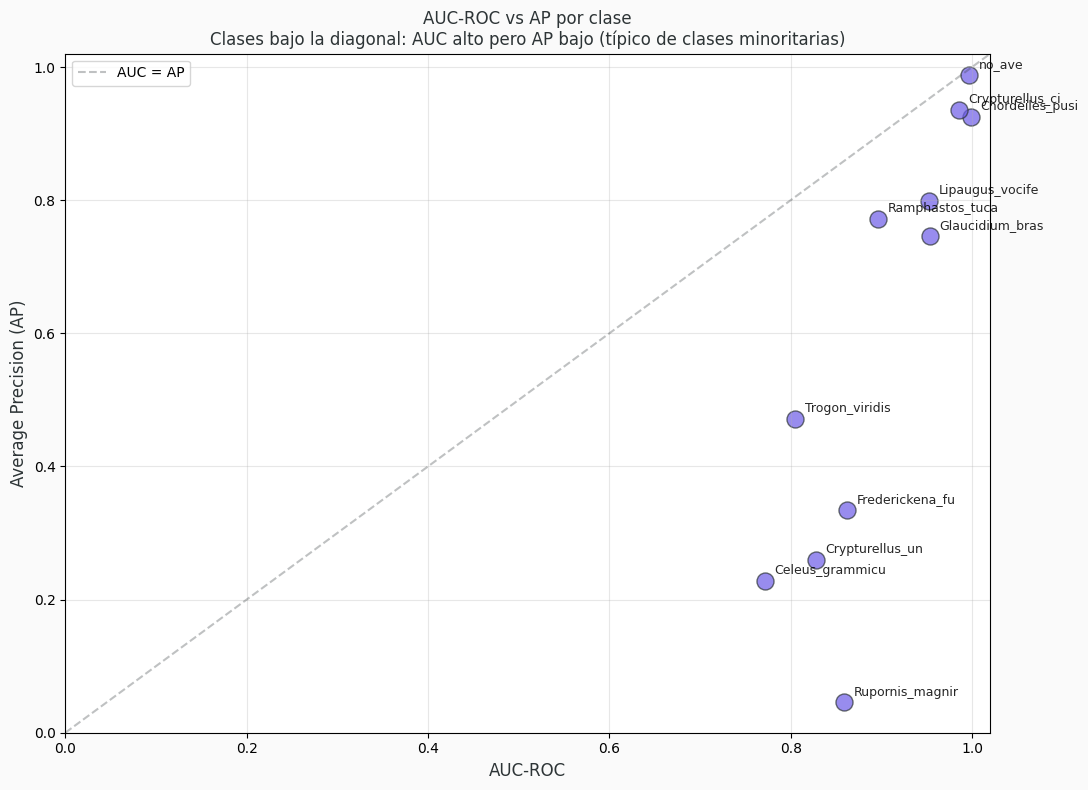

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#FAFAFA')

ap_vals = np.array([ap_per_class[n] for n in class_names])
auc_vals = np.array([auc_per_class[n] for n in class_names])

ax.scatter(auc_vals, ap_vals, s=150, c=COLOR_PRIMARY, alpha=0.7, edgecolors=COLOR_DARK)
for i, name in enumerate(class_names):
    ax.annotate(name[:15], (auc_vals[i], ap_vals[i]),
                fontsize=9, alpha=0.85, xytext=(7, 5), textcoords='offset points')

# Diagonal de referencia
lims = [0, 1.02]
ax.plot(lims, lims, '--', color=COLOR_DARK, alpha=0.3, label='AUC = AP')

ax.set_xlabel('AUC-ROC', fontsize=12, color=COLOR_DARK)
ax.set_ylabel('Average Precision (AP)', fontsize=12, color=COLOR_DARK)
ax.set_title('AUC-ROC vs AP por clase\nClases bajo la diagonal: AUC alto pero AP bajo (típico de clases minoritarias)',
             fontsize=12, color=COLOR_DARK)
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
out_path = RUN_DIR / 'auc_vs_ap_por_clase.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
print(f'Guardada: {out_path}')
plt.show()

## Sección 5 — Tabla resumen de métricas

Generamos una tabla limpia con todas las métricas por clase para incluir directo en el reporte (formato CSV + texto).

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Métricas por clase con argmax (umbral por defecto)
p = precision_score(y_true, y_pred, labels=range(NUM_CLASSES), average=None, zero_division=0)
r = recall_score(y_true, y_pred, labels=range(NUM_CLASSES), average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=range(NUM_CLASSES), average=None, zero_division=0)
support = np.array([(y_true == i).sum() for i in range(NUM_CLASSES)])

df = pd.DataFrame({
    'clase': class_names,
    'support': support,
    'precision': p,
    'recall': r,
    'f1': f1,
    'ap': [ap_per_class[n] for n in class_names],
    'auc_roc': [auc_per_class[n] for n in class_names],
})
df = df.sort_values('f1', ascending=False).reset_index(drop=True)

print('TABLA DE METRICAS POR CLASE (ordenadas por F1):\n')
print(df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Guardar a CSV y a txt
df.to_csv(RUN_DIR / 'metricas_completas.csv', index=False)
with open(RUN_DIR / 'metricas_completas.txt', 'w', encoding='utf-8') as f_out:
    f_out.write('METRICAS COMPLETAS DEL BASELINE\n')
    f_out.write('=' * 70 + '\n')
    f_out.write(df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    f_out.write('\n\nAGREGADOS:\n')
    f_out.write(f'  AP-macro     : {ap_macro:.4f}\n')
    f_out.write(f'  AP-weighted  : {ap_weighted:.4f}\n')
    f_out.write(f'  AUC-ROC macro: {auc_macro:.4f}\n')
    f_out.write(f'  AUC-ROC wt   : {auc_weighted:.4f}\n')

print(f'\nGuardado: metricas_completas.csv y metricas_completas.txt')

TABLA DE METRICAS POR CLASE (ordenadas por F1):

                 clase  support  precision  recall    f1    ap  auc_roc
                no_ave      480      0.846   0.983 0.909 0.988    0.997
 Crypturellus_cinereus      516      0.853   0.857 0.855 0.936    0.985
   Lipaugus_vociferans      318      0.785   0.642 0.706 0.799    0.953
Glaucidium_brasilianum      190      0.738   0.621 0.674 0.746    0.954
    Ramphastos_tucanus      340      0.615   0.706 0.658 0.772    0.897
   Chordeiles_pusillus       36      0.410   0.889 0.561 0.925    0.998
        Trogon_viridis      536      0.440   0.496 0.467 0.471    0.805
    Frederickena_fulva       52      0.429   0.231 0.300 0.334    0.862
Crypturellus_undulatus      202      0.315   0.228 0.264 0.259    0.828
      Celeus_grammicus      244      0.316   0.098 0.150 0.229    0.772
 Rupornis_magnirostris       28      0.032   0.143 0.053 0.045    0.859

Guardado: metricas_completas.csv y metricas_completas.txt


: 